1. Import libraries

In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from catboost import CatBoostRegressor

2. Load dataset

In [3]:
df = pd.read_csv("House_price_prediction.csv")

3. Check dataset

In [4]:
print(df.head())
print(df.columns)


                                      property_name property_type  \
0    5 Bedroom House for sale in Sector 70A Gurgaon         house   
1  5 Bedroom House for sale in Sector 21A Faridabad         house   
2  10 Bedroom House for sale in Sushant Lok Phase 1         house   
3    21 Bedroom House for sale in Sector 54 Gurgaon         house   
4  12 Bedroom House for sale in Sushant Lok Phase 1         house   

            society  price  price_per_sqft    area  \
0  bptp visionnaire   5.25         20115.0  2610.0   
1       independent   5.70        105751.0   539.0   
2       independent   2.10         38251.0   549.0   
3       independent   5.00         43066.0  1161.0   
4       independent   3.00         53763.0   558.0   

                  areaWithType  bedRoom  bathroom balcony  \
0  Plot area 290(242.48 sq.m.)        5         4      3+   
1   Plot area 539(50.07 sq.m.)        5         4       2   
2       Plot area 61(51 sq.m.)       10        10      3+   
3  Plot area 129

In [5]:
# Clean column names
df.columns = df.columns.str.strip()

In [6]:
df = df[['area','bedRoom','bathroom','floorNum','balcony','facing','price','areaWithType','price_per_sqft']]
df = df.dropna()
df = df.reset_index(drop=True)

Conversion of balcony attribute type:

In [7]:
df['balcony'] = df['balcony'].replace('3+', 3)
df['balcony'] = df['balcony'].astype(int)

Conversion of facing attribute type:

In [8]:
df['facing'] = df['facing'].astype('category')

Conversion of areawithtype :

In [9]:
df['area_type'] = df['areaWithType'].astype(str).str.split().str[0]

In [10]:
#Convert to category type:
df['area_type'] = df['area_type'].astype('category')


In [11]:
#Drop original column
df = df.drop(['areaWithType'], axis=1)

Removing price_per_sqft attribute:

In [12]:
df = df.drop(['price_per_sqft'], axis=1)

In [13]:
df.describe()

,area,bedRoom,bathroom,floorNum,balcony,price
count,6.410000e+02,641.000000,641.000000,641.000000,641.000000,641.000000
mean,1.428870e+04,5.455538,5.304212,2.829953,2.455538,5.742652
std,2.863037e+05,3.316385,3.425018,2.688071,0.812964,4.845382
min,4.500000e+01,1.000000,1.000000,0.000000,0.000000,0.130000
25%,1.210000e+03,4.000000,3.000000,2.000000,2.000000,2.000000
50%,2.160000e+03,5.000000,4.000000,3.000000,3.000000,4.700000
75%,3.240000e+03,6.000000,6.000000,3.000000,3.000000,8.000000
max,7.250000e+06,36.000000,36.000000,51.000000,3.000000,31.500000


Check Missing Values

In [14]:
df.isnull().sum()

area         0
bedRoom      0
bathroom     0
floorNum     0
balcony      0
facing       0
price        0
area_type    0
dtype: int64

In [15]:
# verify attribute types
print(df.dtypes)

area          float64
bedRoom         int64
bathroom        int64
floorNum      float64
balcony         int64
facing       category
price         float64
area_type    category
dtype: object


Remove Rows With Missing Values

In [16]:
#Verify again:

df.isnull().sum()

area         0
bedRoom      0
bathroom     0
floorNum     0
balcony      0
facing       0
price        0
area_type    0
dtype: int64

In [17]:
df['price'].describe()

count    641.000000
mean       5.742652
std        4.845382
min        0.130000
25%        2.000000
50%        4.700000
75%        8.000000
max       31.500000
Name: price, dtype: float64

In [17]:
df = df[df['price'] < 12]

4. Define Features and Target

In [18]:
X = df[['area','bedRoom','bathroom','floorNum','balcony','facing','area_type']]
y = df['price']

5. Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

6. Create CatBoost Model

In [20]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

7. Train the Model

In [21]:
model.fit(X_train, y_train, cat_features=['facing','area_type'])

0:	learn: 3.0602507	total: 172ms	remaining: 2m 51s
100:	learn: 1.7841605	total: 3.28s	remaining: 29.2s
200:	learn: 1.5344272	total: 6.6s	remaining: 26.2s
300:	learn: 1.3727064	total: 9.89s	remaining: 23s
400:	learn: 1.2539398	total: 13.2s	remaining: 19.8s
500:	learn: 1.1506086	total: 16.6s	remaining: 16.5s
600:	learn: 1.0660927	total: 19.8s	remaining: 13.2s
700:	learn: 0.9978432	total: 23.1s	remaining: 9.83s
800:	learn: 0.9256457	total: 26.3s	remaining: 6.53s
900:	learn: 0.8723387	total: 29.6s	remaining: 3.25s
999:	learn: 0.8207691	total: 32.8s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

Evaluate Model

In [22]:
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAE:", mae)

RMSE: 1.847353534410137
R2 Score: 0.6245846313057173
MAE: 1.3057545052877413


Feature importance from CatBoost.

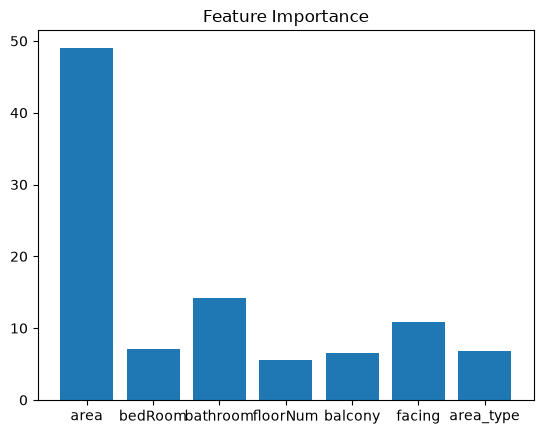

In [23]:
import matplotlib.pyplot as plt

importance = model.get_feature_importance()
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

Save Model (for your web app)

In [24]:
import pickle

pickle.dump(model, open("catboost_model.pkl","wb"))

Generate the SHAP values

In [25]:
import shap
print(shap.__version__)
# Create SHAP Explainer
explainer = shap.TreeExplainer(model)

# Generate SHAP values
shap_values = explainer(X_train)

print("SHAP values generated successfully!")

c:\Users\yusrahome\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.52.0
SHAP values generated successfully!


Generate  and save the SHAP Summary Plot

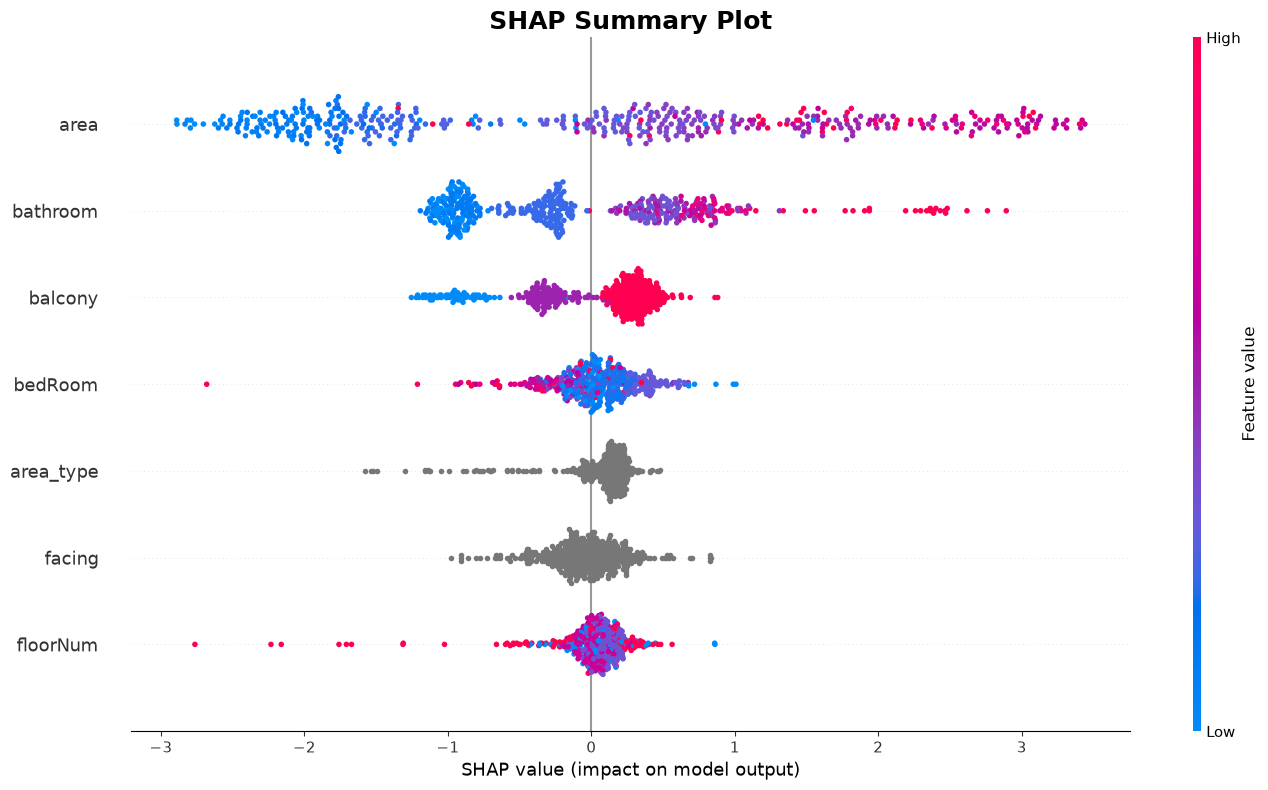

Summary Plot Saved Successfully!


In [35]:

# Create the plot
shap.summary_plot(
    shap_values,
    X_train,
    show=False
)

# Get the current figure and resize it
fig = plt.gcf()
fig.set_size_inches(14, 8)

plt.title("SHAP Summary Plot", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.savefig(
    r"static\shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.5
)

plt.show()      # Display in notebook
plt.close(fig)  # Close after saving

print("Summary Plot Saved Successfully!")

Feature Importance Plot and Save → SHAP Bar Plot 

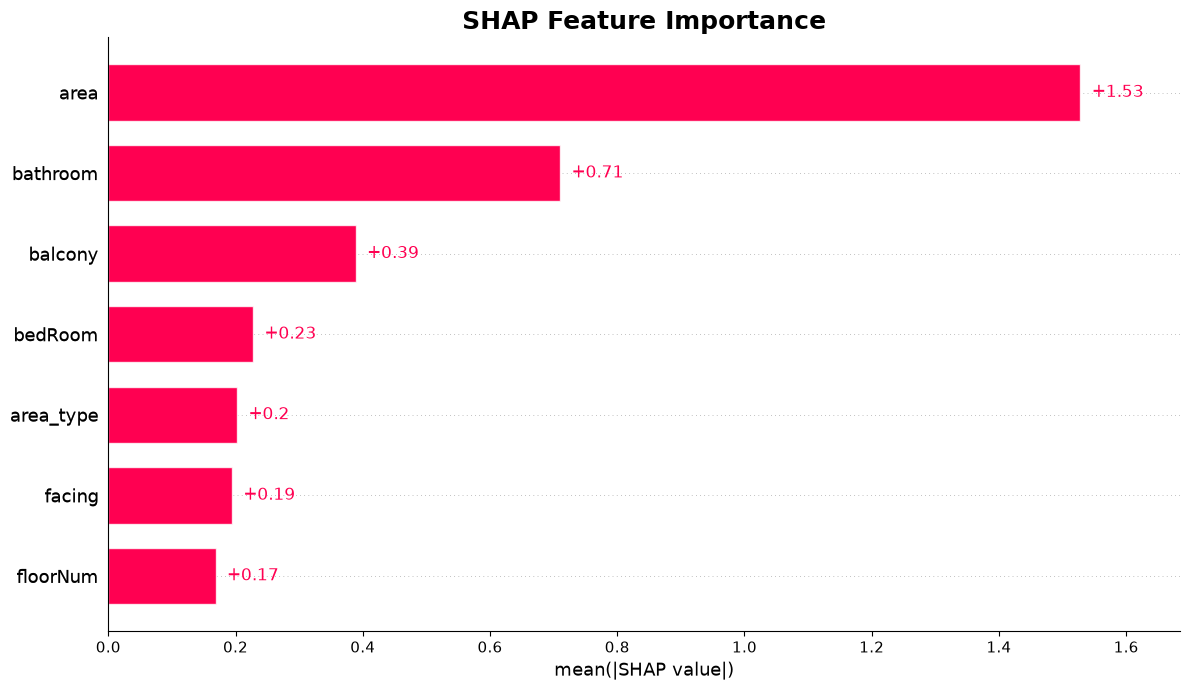

Feature Importance Plot Saved Successfully!


In [36]:

shap.plots.bar(
    shap_values,
    max_display=len(X_train.columns),
    show=False
)

fig = plt.gcf()
fig.set_size_inches(12, 7)

plt.title(
    "SHAP Feature Importance",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    r"static\shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.5
)

plt.show()
plt.close(fig)

print("Feature Importance Plot Saved Successfully!")

Save the information needed for SHAP// SHAP Output → Summary Plot + Waterfall Plot + Contribution Table

In [37]:

# Save feature names
with open("feature_names.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save background data for SHAP
X_train.to_pickle("background_data.pkl")